# Hoi quy nhi phan

In [90]:
# %load ../standard_import.txt
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score
from sklearn.metrics import confusion_matrix
# from sklearn.metrics import plot_confusion_matrix   <-- DELETE OR COMMENT THIS OUT
from sklearn.metrics import ConfusionMatrixDisplay
%matplotlib inline
plt.style.use('seaborn-v0_8-white')

### Load dataset

In [92]:
df = pd.read_csv('Data/Default.csv')
df['student2'] = df.student.factorize()[0]
df['default2'] = df.default.factorize()[0]
df=df.drop(['default','student'],axis=1)
df.head(3)

,balance,income,student2,default2
0,729.526495,44361.625074,0,0
1,817.180407,12106.134700,1,0
2,1073.549164,31767.138947,0,0


In [93]:
x=df['balance']
x=x/x.max()
y=df['default2']

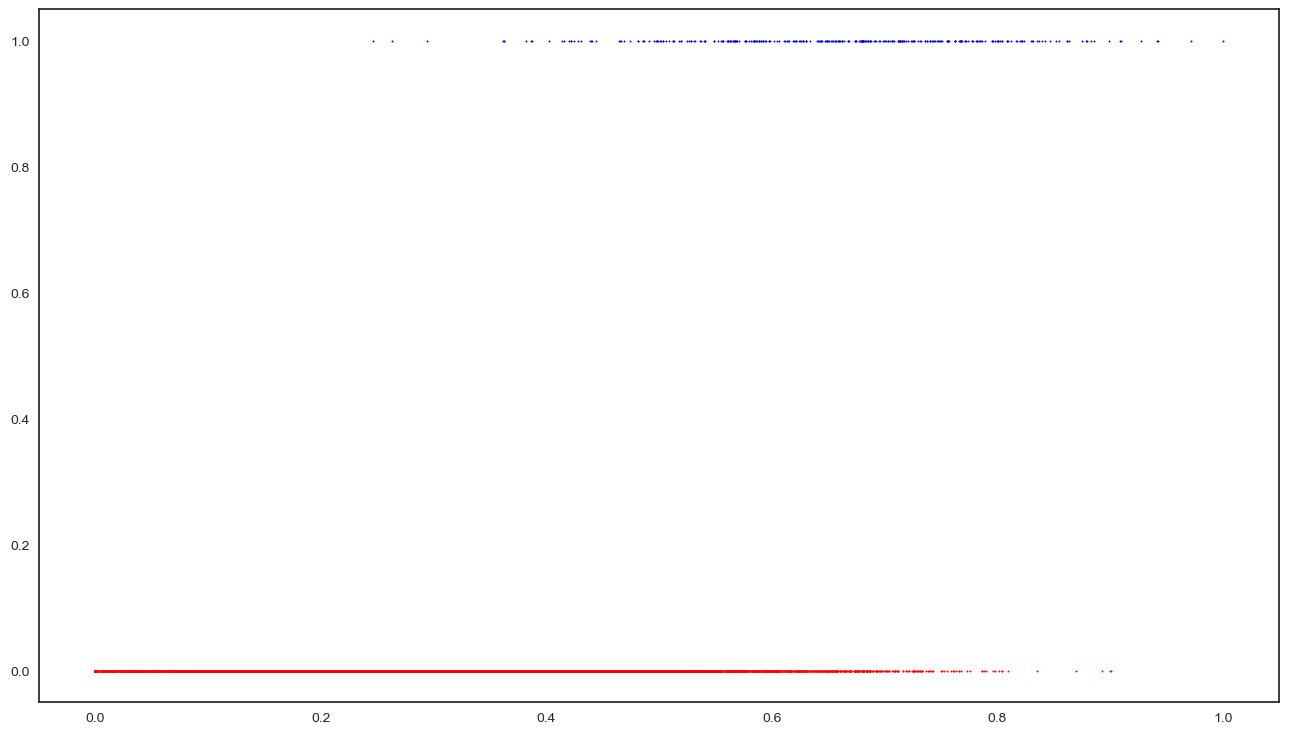

In [94]:
plt.figure(figsize=(16,9))
id0=y==0
id1=y==1
plt.scatter(x[id0],y[id0],c='red',s=1)
plt.scatter(x[id1],y[id1],c='blue',s=1)
plt.show()

In [95]:
x=x.values.reshape(-1,1)
x.shape

(10000, 1)

In [96]:
model = LogisticRegression()
model.fit(x, y)
print(model.intercept_)
print(model.coef_[0])

[-8.80925348]
[11.50214647]


Phương trình mô hình trong trường hợp này
Hồi quy Logistic tính toán xác suất $p = P(y = 1 | x)$ bằng cách đưa tổ hợp tuyến tính $z$ vào hàm Sigmoid $\sigma(z)$:

a) Biểu thức tuyến tính (Log-Odds / Logit):
$$z = w_0 + w_1 \cdot x$$

Thay các giá trị cụ thể thu được từ model.intercept_ ($w_0$) và model.coef_[0] ($w_1$): $$z = -8.8093 + 11.5021 \cdot x$$

b) Mô hình xác suất đầy đủ (Hàm Sigmoid):
$$p(x) = P(y=1|x) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-(-8.8093 + 11.5021 \cdot x)}}$$

Hoặc viết gọn lại: $$p(x) = \frac{1}{1 + e^{8.8093 - 11.5021 \cdot x}}$$

Trong đó:

$x$: Số dư tài khoản đã chuẩn hóa (df['balance'] / df['balance'].max()).
$y$: Trạng thái vỡ nợ (1: vỡ nợ / default, 0: không vỡ nợ).


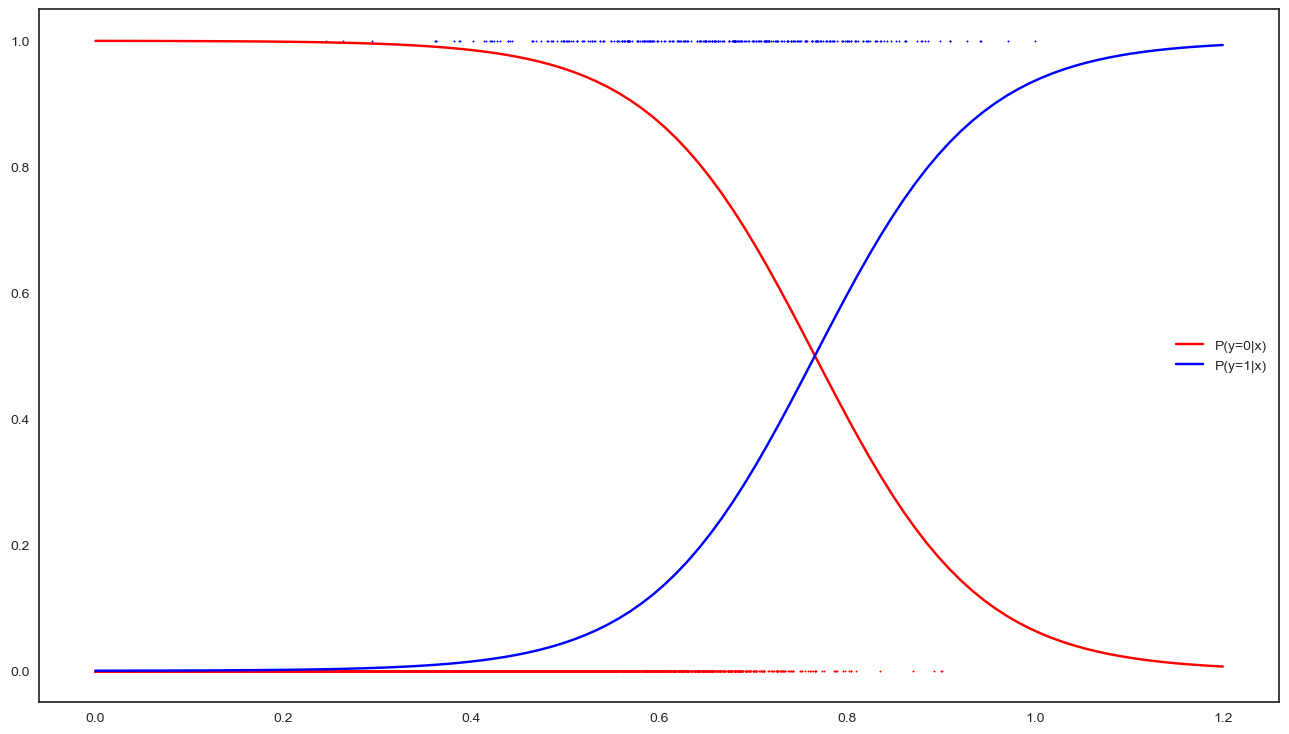

In [44]:
plt.figure(figsize=(16,9))
id0=y==0
id1=y==1
plt.scatter(x[id0],y[id0],c='red',s=1)
plt.scatter(x[id1],y[id1],c='blue',s=1)
xx=np.linspace(0,1.2,100).reshape(-1,1)
yy=1/(1+np.exp(model.intercept_+model.coef_[0][0]*xx))
plt.plot(xx,yy,c='red',label='P(y=0|x)')
plt.plot(xx,1-yy,c='blue',label='P(y=1|x)')
plt.legend(loc='best')
plt.show()

In [45]:
y_pred=model.predict(x)

In [46]:
confusion_matrix(y, y_pred)

array([[9647,   20],
       [ 262,   71]])

<Figure size 800x800 with 0 Axes>

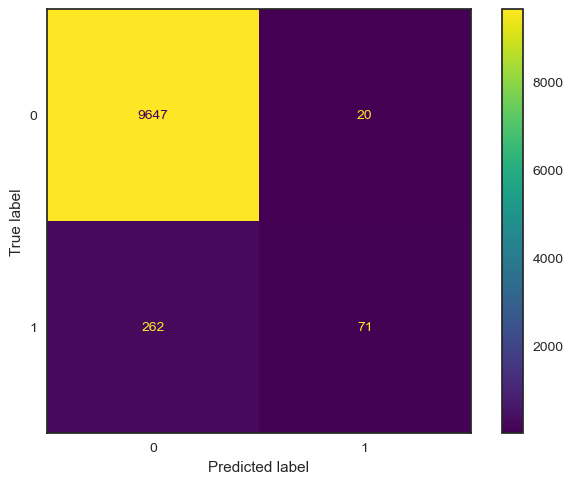

In [47]:
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay.from_estimator(model,x,y)
plt.show()

In [48]:
pred_prob = model.predict_proba(x)

In [49]:
from sklearn.metrics import roc_curve

fpr, tpr, thresh = roc_curve(y, pred_prob[:,1], pos_label=1)


In [50]:
from sklearn.metrics import roc_auc_score
# auc scores
auc_score = roc_auc_score(y, pred_prob[:,1])
auc_score

0.9479784946837808

In [51]:
# roc curve for tpr = fpr 
random_probs = [0 for i in range(len(y))]
p_fpr, p_tpr, _ = roc_curve(y, random_probs, pos_label=1)

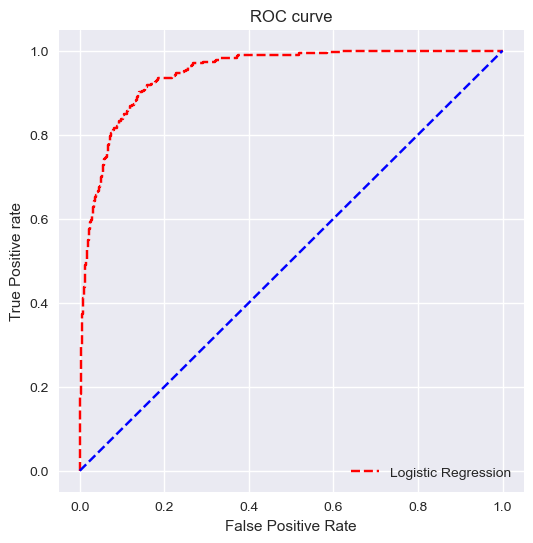

In [52]:
# matplotlib
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(6,6))
# plot roc curves
plt.plot(fpr, tpr, linestyle='--',color='red', label='Logistic Regression')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.savefig('ROC',dpi=300)
plt.show();

In [53]:
pred_prob = model.predict_proba(x)[:,1]

In [54]:
cut_off=np.linspace(0,1,11)
cut_off

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [55]:
CM=[]
for cutpoint in cut_off:
    y_pred=pred_prob>=cutpoint
    cm=confusion_matrix(y, y_pred)
    CM.append(cm.flatten())

In [56]:
df=pd.DataFrame(CM,columns=['TP','FN','FP','TN'])
df

,TP,FN,FP,TN
0,0,9667,0,333
1,9089,578,85,248
2,9436,231,141,192
3,9577,90,195,138
4,9625,42,233,100
5,9647,20,262,71
6,9658,9,293,40
7,9663,4,312,21
8,9664,3,325,8
9,9667,0,331,2


In [57]:
df['TPR']=df['TP']/(df['TP']+df['FN'])
df['FPR']=df['FP']/(df['FP']+df['TN'])

In [58]:
df

,TP,FN,FP,TN,TPR,FPR
0,0,9667,0,333,0.000000,0.000000
1,9089,578,85,248,0.940209,0.255255
2,9436,231,141,192,0.976104,0.423423
3,9577,90,195,138,0.990690,0.585586
4,9625,42,233,100,0.995655,0.699700
5,9647,20,262,71,0.997931,0.786787
6,9658,9,293,40,0.999069,0.879880
7,9663,4,312,21,0.999586,0.936937
8,9664,3,325,8,0.999690,0.975976
9,9667,0,331,2,1.000000,0.993994


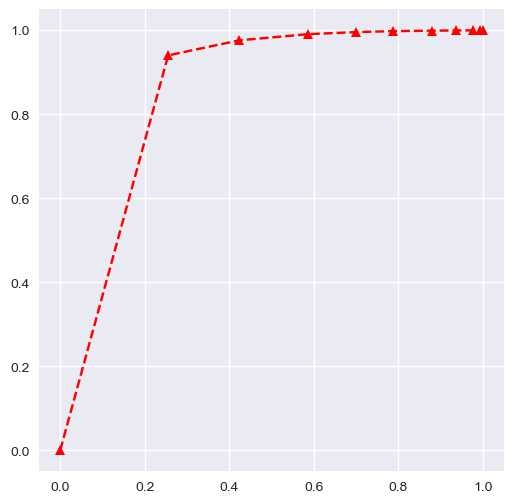

In [59]:
plt.figure(figsize=(6,6))
plt.plot(df['FPR'],df['TPR'],marker='^',c='red',linestyle='--')
plt.show()

# Multiple logistic regression

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [61]:
df = pd.read_csv('Data/Default.csv')
df['student2'] = df.student.factorize()[0]
df['default2'] = df.default.factorize()[0]
df=df.drop(['default','student'],axis=1)
df.head(3)

,balance,income,student2,default2
0,729.526495,44361.625074,0,0
1,817.180407,12106.134700,1,0
2,1073.549164,31767.138947,0,0


In [62]:
X=df[['balance','income','student2']].values
y=df['default2'].values
print(X.shape,y.shape)

(10000, 3) (10000,)


In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [64]:
model = LogisticRegression().fit(X_train, y_train)

In [65]:
print(model.intercept_,model.coef_)

[-11.10816439] [[ 5.78857147e-03  5.82361683e-06 -4.67458504e-01]]


### Viết rõ mô hình hồi quy logistic nhiều biến

Tổ hợp tuyến tính $z$:
$$z = -2.9227 + 0.004108 \cdot x_1 - 0.0001356 \cdot x_2 - 3.8077 \cdot x_3$$

Mô hình xác suất $P(y=1 \mid x_1, x_2, x_3)$:
$$P(y=1 \mid x_1, x_2, x_3) = \frac{1}{1 + e^{-(-2.9227 + 0.004108 \cdot x_1 - 0.0001356 \cdot x_2 - 3.8077 \cdot x_3)}}$$

Hoặc viết gọn lại:
$$P(y=1 \mid x_1, x_2, x_3) = \frac{1}{1 + e^{2.9227 - 0.004108 \cdot x_1 + 0.0001356 \cdot x_2 + 3.8077 \cdot x_3}}$$

Trong đó:
- $x_1$: `balance` (Số dư tài khoản)
- $x_2$: `income` (Thu nhập)
- $x_3$: `student2` (1: Sinh viên, 0: Không phải sinh viên)
- $y$: `default2` (1: Vỡ nợ, 0: Không vỡ nợ)


In [66]:
print(round(model.score(X_train, y_train), 4), round(model.score(X_test, y_test), 4))

0.9734 0.9733


In [67]:
p_test=model.predict_proba(X_test)[:,1]
p_train=model.predict_proba(X_train)[:,1]

In [68]:
cut_off=np.linspace(0,1,11)
CM_test=[]
CM_train=[]
for cutpoint in cut_off:
    y_test_pred=p_test>=cutpoint
    y_train_pred=p_train>=cutpoint
    cm=confusion_matrix(y_test, y_test_pred)
    CM_test.append(cm.flatten())
    cm=confusion_matrix(y_train, y_train_pred)
    CM_train.append(cm.flatten())
    

In [69]:
df_test=pd.DataFrame(CM_test,columns=['TP','FN','FP','TN'])
df_train=pd.DataFrame(CM_train,columns=['TP','FN','FP','TN'])

In [70]:
df_test['TPR']=df_test['TP']/(df_test['TP']+df_test['FN'])
df_test['FPR']=df_test['FP']/(df_test['FP']+df_test['TN'])
df_train['TPR']=df_train['TP']/(df_train['TP']+df_train['FN'])
df_train['FPR']=df_train['FP']/(df_train['FP']+df_train['TN'])

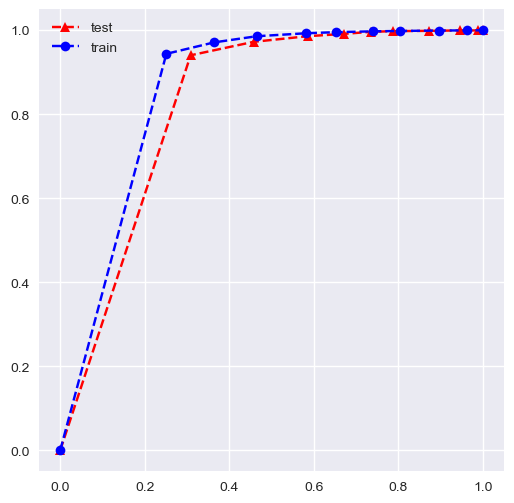

In [71]:
plt.figure(figsize=(6,6))
plt.plot(df_test['FPR'],df_test['TPR'],marker='^',c='red',linestyle='--',label='test')
plt.plot(df_train['FPR'],df_train['TPR'],marker='o',c='blue',linestyle='--',label='train')
plt.legend()
plt.show()

### 4. HỒI QUY ĐA LỚP

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.datasets import load_iris

In [73]:
X=load_iris().data
y=load_iris().target

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
model = LogisticRegression(multi_class='multinomial')
model.fit(X_train,y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [76]:
b=model.intercept_
w=model.coef_
print(b)
print(w)

[  9.00953843   1.86864855 -10.87818698]
[[-0.39352486  0.96242398 -2.37516107 -0.9987522 ]
 [ 0.50847792 -0.25477254 -0.21300601 -0.77574639]
 [-0.11495306 -0.70765144  2.58816708  1.77449859]]


In [77]:
x_test=X_test[0]
z=np.dot(x_test,w.T)+b
print(z)

[-3.05793572  2.32497683  0.7329589 ]


In [78]:
proba=np.exp(z)/np.sum(np.exp(z))
print(proba)

[0.00380299 0.82773992 0.16845709]


## 4.4 Linear Discriminant Analysis
### Table 4.4 


In [ ]:
X = df[['balance', 'income', 'student2']].values
y = df.default2.values

lda = LinearDiscriminantAnalysis(solver='svd')
y_pred = lda.fit(X, y).predict(X)

df_ = pd.DataFrame({'True default status': y,
                    'Predicted default status': y_pred})
df_.replace(to_replace={0:'No', 1:'Yes'}, inplace=True)

df_.groupby(['Predicted default status','True default status']).size().unstack('True default status')

In [ ]:
print(classification_report(y, y_pred, target_names=['No', 'Yes']))

### Table 4.5
Instead of using the probability of 50% as decision boundary, we say that a probability of default of 20% is to be classified as 'Yes'.

In [ ]:
decision_prob = 0.2
y_prob = lda.fit(X, y).predict_proba(X)

df_ = pd.DataFrame({'True default status': y,
                    'Predicted default status': y_prob[:,1] > decision_prob})
df_.replace(to_replace={0:'No', 1:'Yes', 'True':'Yes', 'False':'No'}, inplace=True)

df_.groupby(['Predicted default status','True default status']).size().unstack('True default status')

#  Lab

### 4.6.3 Linear Discriminant Analysis

In [ ]:
df = pd.read_csv('Data/Smarket.csv', usecols=range(1,10), index_col=0, parse_dates=True)

In [ ]:
X_train = df[:'2004'][['Lag1','Lag2']]
y_train = df[:'2004']['Direction']

X_test = df['2005':][['Lag1','Lag2']]
y_test = df['2005':]['Direction']

lda = LinearDiscriminantAnalysis()
pred = lda.fit(X_train, y_train).predict(X_test)

In [ ]:
lda.priors_

In [ ]:
lda.means_

In [ ]:
# These do not seem to correspond to the values from the R output in the book?
lda.coef_

In [ ]:
confusion_matrix(y_test, pred).T

In [ ]:
print(classification_report(y_test, pred, digits=3))

In [ ]:
pred_p = lda.predict_proba(X_test)

In [ ]:
np.unique(pred_p[:,1]>0.5, return_counts=True)

In [ ]:
np.unique(pred_p[:,1]>0.9, return_counts=True)

### 4.6.4 Quadratic Discriminant Analysis

In [ ]:
qda = QuadraticDiscriminantAnalysis()
pred = qda.fit(X_train, y_train).predict(X_test)

In [ ]:
qda.priors_

In [ ]:
qda.means_

In [ ]:
confusion_matrix(y_test, pred).T

In [ ]:
print(classification_report(y_test, pred, digits=3))

### 4.6.5 K-Nearest Neighbors

In [ ]:
knn = neighbors.KNeighborsClassifier(n_neighbors=1)
pred = knn.fit(X_train, y_train).predict(X_test)
print(confusion_matrix(y_test, pred).T)
print(classification_report(y_test, pred, digits=3))

In [ ]:
knn = neighbors.KNeighborsClassifier(n_neighbors=3)
pred = knn.fit(X_train, y_train).predict(X_test)
print(confusion_matrix(y_test, pred).T)
print(classification_report(y_test, pred, digits=3))

### 4.6.6 An Application to Caravan Insurance Data

#### K-Nearest Neighbors

In [ ]:
# In R, I exported the dataset from package 'ISLR' to a csv file
df = pd.read_csv('Data/Caravan.csv')
y = df.Purchase
X = df.drop('Purchase', axis=1).astype('float64')
X_scaled = preprocessing.scale(X)

X_train = X_scaled[1000:,:]
y_train = y[1000:]
X_test = X_scaled[:1000,:]
y_test = y[:1000]

def KNN(n_neighbors=1, weights='uniform'):
    clf = neighbors.KNeighborsClassifier(n_neighbors, weights)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    score = clf.score(X_test, y_test)
    return(pred, score, clf.classes_)

def plot_confusion_matrix(cm, classes, n_neighbors, title='Confusion matrix (Normalized)',
                          cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Normalized confusion matrix: KNN-{}'.format(n_neighbors))
    plt.colorbar()
    plt.xticks(np.arange(2), classes)
    plt.yticks(np.arange(2), classes)
    plt.tight_layout()
    plt.xlabel('True label',rotation='horizontal', ha='right')
    plt.ylabel('Predicted label')
    plt.show()

In [ ]:
for i in [1,3,5]:
    pred, score, classes = KNN(i)
    cm = confusion_matrix(y_test, pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plot_confusion_matrix(cm_normalized.T, classes, n_neighbors=i)
    cm_df = pd.DataFrame(cm.T, index=classes, columns=classes)
    cm_df.index.name = 'Predicted'
    cm_df.columns.name = 'True'
    print(cm_df)    
    print(pd.DataFrame(precision_score(y_test, pred, average=None),
                       index=classes, columns=['Precision']))        

####  Logistic Regression

In [ ]:
regr = skl_lm.LogisticRegression()
regr.fit(X_train, y_train)

In [ ]:
pred = regr.predict(X_test)
cm_df = pd.DataFrame(confusion_matrix(y_test, pred).T, index=regr.classes_,
                     columns=regr.classes_)
cm_df.index.name = 'Predicted'
cm_df.columns.name = 'True'
print(cm_df)
print(classification_report(y_test, pred))

In [ ]:
pred_p = regr.predict_proba(X_test)
cm_df = pd.DataFrame({'True': y_test, 'Pred': pred_p[:,1] > .25})
cm_df.Pred.replace(to_replace={True:'Yes', False:'No'}, inplace=True)
print(cm_df.groupby(['True', 'Pred']).size().unstack('True').T)
print(classification_report(y_test, cm_df.Pred))